### **Industrial Machine Anomaly Detection Using DBSCAN**
---

#### **Import Libraries**

In [29]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN, KMeans
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA

#### **Project Objective**

In [30]:
# This project aims to apply DBSCAN clustering 
# to industrial sensor data to identify normal 
# operating patterns and detect unusual operating conditions. 
# The detected anomalies will then be analyzed against machine failure records
# to evaluate their potential relevance to predictive maintenance and early failure detection.

#### **Load Dataset**

In [31]:
df = pd.read_csv("ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [32]:
df.shape

(10000, 14)

#### **Data Understanding**

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [34]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
UDI,10000.0,5000.50000,2886.895680,1.0,2500.75,5000.5,7500.25,10000.0
Air temperature [K],10000.0,300.00493,2.000259,295.3,298.30,300.1,301.50,304.5
Process temperature [K],10000.0,310.00556,1.483734,305.7,308.80,310.1,311.10,313.8
Rotational speed [rpm],10000.0,1538.77610,179.284096,1168.0,1423.00,1503.0,1612.00,2886.0
Torque [Nm],10000.0,39.98691,9.968934,3.8,33.20,40.1,46.80,76.6
Tool wear [min],10000.0,107.95100,63.654147,0.0,53.00,108.0,162.00,253.0
Machine failure,10000.0,0.03390,0.180981,0.0,0.00,0.0,0.00,1.0
TWF,10000.0,0.00460,0.067671,0.0,0.00,0.0,0.00,1.0
HDF,10000.0,0.01150,0.106625,0.0,0.00,0.0,0.00,1.0
PWF,10000.0,0.00950,0.097009,0.0,0.00,0.0,0.00,1.0


In [35]:
df.describe(include="object").T

,count,unique,top,freq
Product ID,10000,10000,L57163,1
Type,10000,3,L,6000


In [36]:
df.isnull().sum()

UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

In [37]:
df.duplicated().sum()

np.int64(0)

#### **EDA**
---

##### **1- Univariate Analysis**

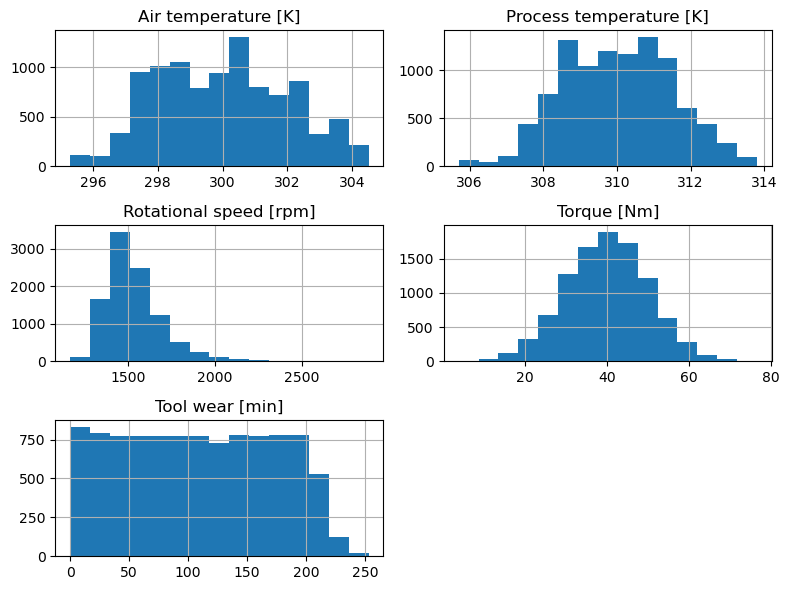

In [38]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

df[features].hist(figsize=(8, 6), bins=15)

plt.tight_layout()
plt.show()

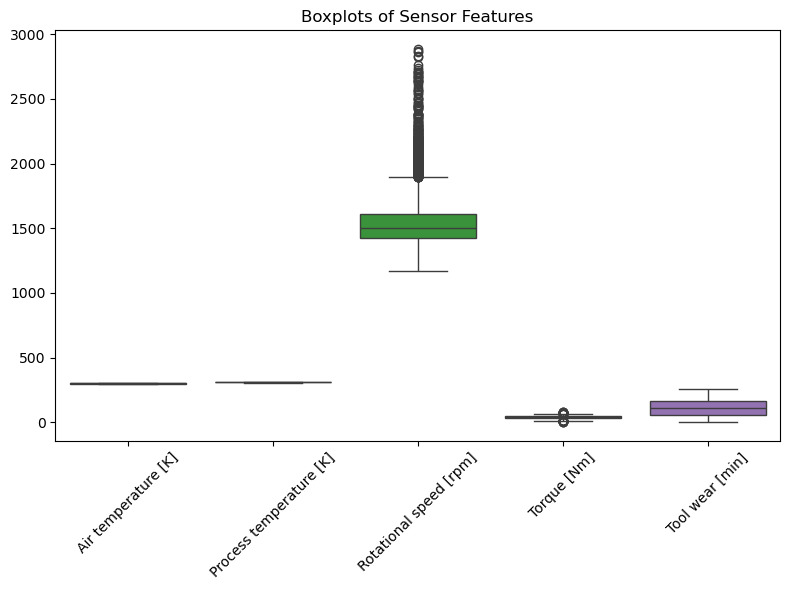

In [39]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df[features])

plt.xticks(rotation=45)
plt.title('Boxplots of Sensor Features')
plt.tight_layout()
plt.show()

##### **2- Multivariate Analysis**

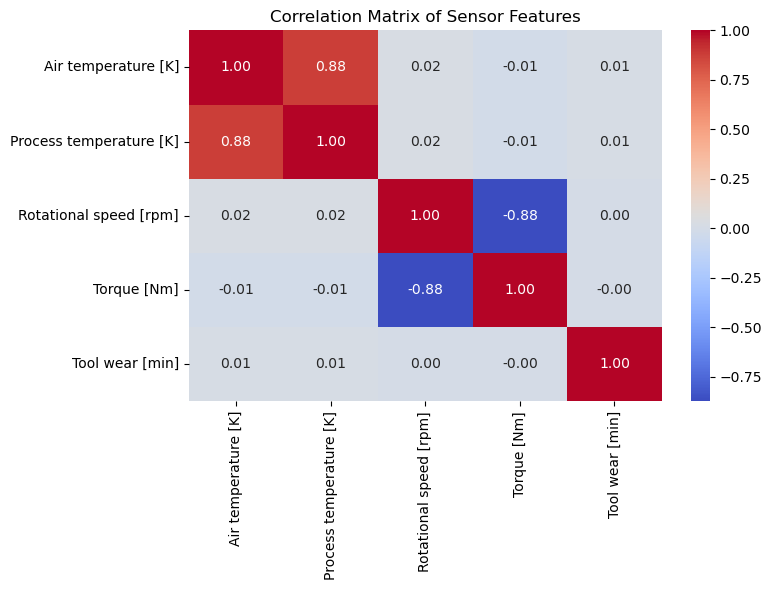

In [40]:
plt.figure(figsize=(8, 6))

corr = df[features].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Matrix of Sensor Features')
plt.tight_layout()
plt.show()

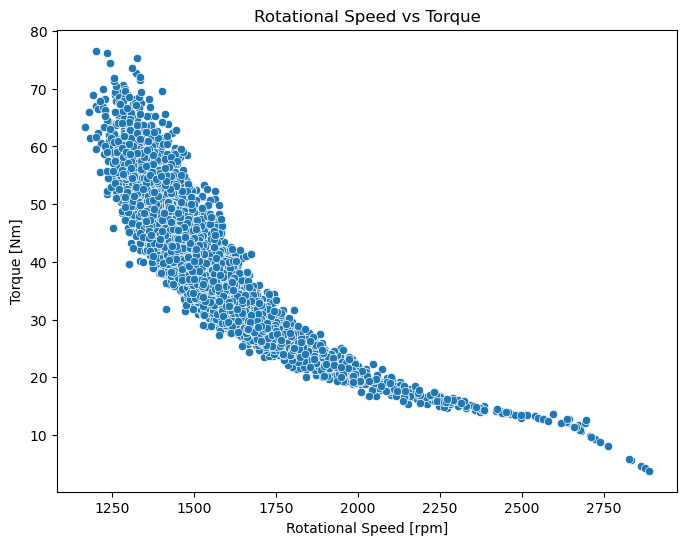

In [41]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Rotational speed [rpm]',
    y='Torque [Nm]'
)

plt.title('Rotational Speed vs Torque')
plt.xlabel('Rotational Speed [rpm]')
plt.ylabel('Torque [Nm]')
plt.show()

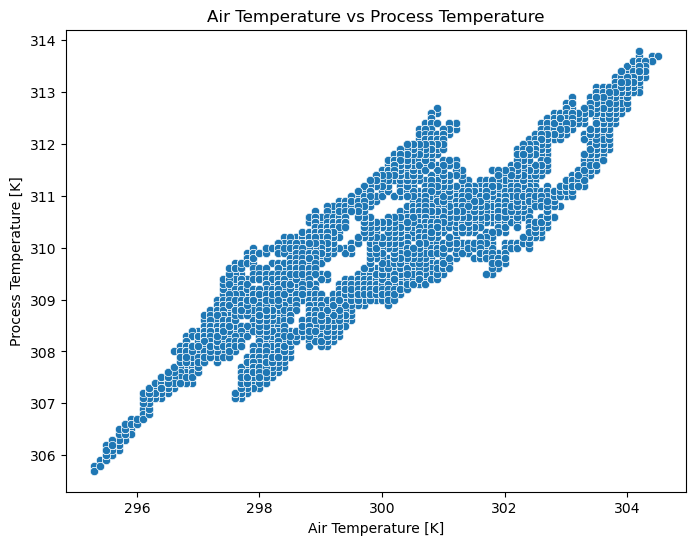

In [42]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=df,
    x='Air temperature [K]',
    y='Process temperature [K]'
)

plt.title('Air Temperature vs Process Temperature')
plt.xlabel('Air Temperature [K]')
plt.ylabel('Process Temperature [K]')
plt.show()

### **Feature Selection**

In [43]:
features = [
    'Air temperature [K]',
    'Process temperature [K]',
    'Rotational speed [rpm]',
    'Torque [Nm]',
    'Tool wear [min]'
]

X = df[features].copy()
X.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,298.1,308.6,1551,42.8,0
1,298.2,308.7,1408,46.3,3
2,298.1,308.5,1498,49.4,5
3,298.2,308.6,1433,39.5,7
4,298.2,308.7,1408,40.0,9


### **Feature Scaling**

In [44]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled[:5]

array([[-9.52389443e-01, -9.47359888e-01,  6.81851403e-02,
         2.82199756e-01, -1.69598374e+00],
       [-9.02393410e-01, -8.79959002e-01, -7.29471505e-01,
         6.33308020e-01, -1.64885170e+00],
       [-9.52389443e-01, -1.01476077e+00, -2.27449840e-01,
         9.44289625e-01, -1.61743034e+00],
       [-9.02393410e-01, -9.47359888e-01, -5.90021043e-01,
        -4.88451785e-02, -1.58600898e+00],
       [-9.02393410e-01, -8.79959002e-01, -7.29471505e-01,
         1.31314491e-03, -1.55458761e+00]])

### **Finding the Optimal eps**

In [45]:
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)

distances, indices = neighbors_fit.kneighbors(X_scaled)
distances = np.sort(distances[:, 4])

In [46]:
# Index 0 → The point itself
# Index 1 → The 1st nearest neighbor
# Index 2 → The 2nd nearest neighbor
# Index 3 → The 3rd nearest neighbor
# Index 4 → The 4th nearest neighbor after the point itself

In [47]:
# => K-Distance Plot — Steps

# 1. **Calculate the distances to the nearest neighbors.**
# 2. **Choose the K-th neighbor distance for each point.**
# 3. **Sort all K-th neighbor distances in ascending order.**
# 4. **Plot the sorted distances.**
# 5. **Find the Elbow point.**
# 6. **Use the Elbow distance as a starting value for `eps`.**


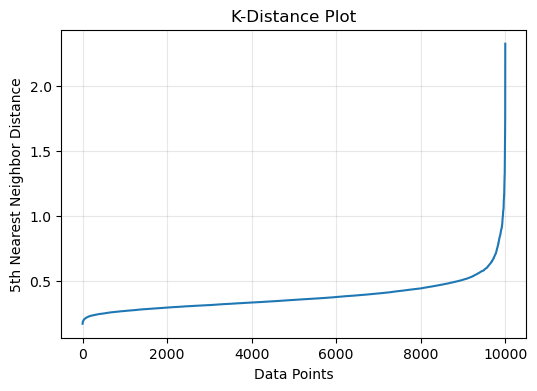

In [48]:
plt.figure(figsize=(6, 4))

plt.plot(distances)

plt.xlabel('Data Points')
plt.ylabel('5th Nearest Neighbor Distance')
plt.title('K-Distance Plot')

plt.grid(alpha=0.3)
plt.show()

### **=> Apply DBSCAN**

In [49]:
dbscan = DBSCAN(
    eps=0.6,
    min_samples=10
)

clusters = dbscan.fit_predict(X_scaled)
clusters[:10]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [50]:
unique_labels = np.unique(clusters)

print("Cluster labels:", unique_labels)
print("Number of clusters:", len(unique_labels[unique_labels != -1]))
print("Number of noise points:", np.sum(clusters == -1))

Cluster labels: [-1  0  1]
Number of clusters: 2
Number of noise points: 432


In [51]:
pd.Series(clusters).value_counts().sort_index()

-1     432
 0    9556
 1      12
Name: count, dtype: int64

In [52]:
df['Cluster'] = clusters
df.groupby('Cluster')[features].mean()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
Cluster,,,,,
-1,299.863426,309.841435,1881.155093,32.197685,109.694444
0,300.007022,310.009858,1522.847635,40.361270,107.859565
1,303.433333,312.491667,1897.500000,22.283333,118.000000


### **Anomaly Detection**

In [53]:
df['Anomaly'] = (df['Cluster'] == -1).astype(int)
df[['Cluster', 'Anomaly', 'Machine failure']].head()

,Cluster,Anomaly,Machine failure
0,0,0,0
1,0,0,0
2,0,0,0
3,0,0,0
4,0,0,0


In [54]:
pd.crosstab(
    df['Machine failure'],
    df['Anomaly'],
    rownames=['Actual Failure'],
    colnames=['DBSCAN Anomaly']
)

DBSCAN Anomaly,0,1
Actual Failure,,
0,9331,330
1,237,102


In [55]:
# DBSCAN found meaningful anomalies, but it is not 
# a strong standalone failure detector with these parameters

### **PCA Visualization**

In [56]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca.shape

(10000, 2)

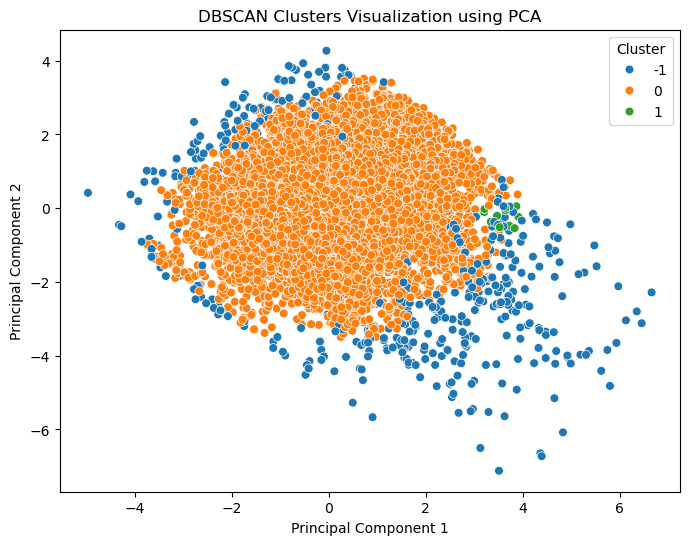

In [57]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=clusters,
    palette='tab10',
    s=40
)

plt.title('DBSCAN Clusters Visualization using PCA')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster')

plt.show()

In [ ]:
# The PCA plot does not mean that the clusters must be clearly separated.

# PCA reduces the data from:
# 5 features → 2 Principal Components

# Therefore, points that were separated in the original
# 5-dimensional space may appear overlapping after being projected
# onto only two dimensions for visualization.

In [58]:
failure_analysis = df.groupby('Cluster')['Machine failure'].agg(
    Total_Points='count',
    Failures='sum',
    Failure_Rate='mean'
)

failure_analysis['Failure_Rate'] *= 100
failure_analysis

,Total_Points,Failures,Failure_Rate
Cluster,,,
-1,432,102,23.611111
0,9556,237,2.480117
1,12,0,0.000000


In [ ]:
# DBSCAN detected 432 anomalous points based on unusual patterns in the machine's sensor features.
# Among these anomalies, 102 points were associated with an actual machine failure.
# This suggests that abnormal machine behavior may be strongly related to machine failures.

In [ ]:
# Anomalies have a failure rate about 9.5 times higher than normal points.
# This shows that the anomalies detected by DBSCAN are strongly associated with machine failures.
# Therefore, the clustering results have meaningful practical/business value.

In [59]:
df['Point_Type'] = df['Cluster'].apply(
    lambda x: 'DBSCAN Anomaly' if x == -1 else 'Normal'
)

In [66]:
df['Cluster'].value_counts()

Cluster
 0    9556
-1     432
 1      12
Name: count, dtype: int64

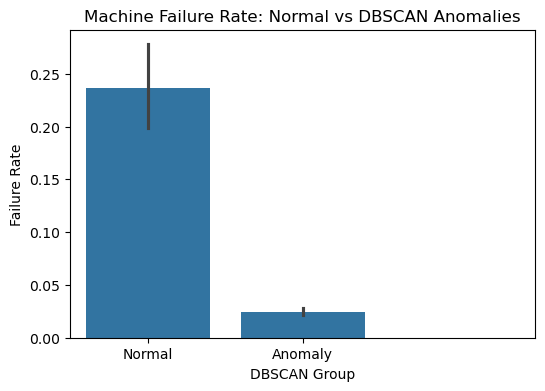

In [65]:
plt.figure(figsize=(6, 4))

sns.barplot(
    data=df,
    x='Cluster',
    y='Machine failure',
    estimator='mean'
)

plt.title('Machine Failure Rate: Normal vs DBSCAN Anomalies')
plt.xlabel('DBSCAN Group')
plt.ylabel('Failure Rate')
plt.xticks(
    [0, 1],
    ['Normal', 'Anomaly']
)

plt.show()

In [67]:
failure_rate = (
    df.groupby('Point_Type')['Machine failure']
      .mean()
      .mul(100)
)

failure_rate

Point_Type
DBSCAN Anomaly    23.611111
Normal             2.477007
Name: Machine failure, dtype: float64